In [1]:
from phasic import (
    Graph, with_ipv, StateIndexer, Property, set_log_level, 
    clear_model_cache, clear_jax_cache, cache_info,
    print_model_cache_info, print_jax_cache_info
)
import pandas as pd
import numpy as np
from scipy.stats import binom, betabinom, beta
from scipy.special import comb

import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_format = 'svg'
from functools import partial
from itertools import combinations_with_replacement
all_pairs = partial(combinations_with_replacement, r=2)

from vscodenb import set_vscode_theme
set_vscode_theme()
sns.set_palette('tab10')


def kahan_sum(x: np.ndarray) -> float:
    x = np.sort(x)
    s = x[0]
    c = 0.0
    for i in range(1, len(x)):
        y = x[i] - c
        t = s + y
        c = (t - s) - y
        s = t
    return s


def selection_graph(state, N=None, bin_size=None, sel_coef=None, 
                    freqs=None, indexer=None):

    transitions = []
    
    freqs = np.arange(0, N, bin_size) / N
    assert not (freqs.size - 2) % bin_size
    f_idx = state[indexer.freq]

    # lineage counts
    n_lineages = state[indexer.lineage.indices()].sum()
    n_derived = state[indexer.lineage.p2i(is_deriv=1)].sum()

    if n_lineages <= 1:
        return []  # absorbing
       
    if f_idx == 0 and n_derived > 1:
        # zero frequency with multiple derived lineages
        assert 0, 'Should not occur'
        return transitions
    
    # frequency
    for child_f_idx in range(len(freqs)):
        if child_f_idx == f_idx:
            # same frequency bin
            continue
        if child_f_idx == 0 and n_derived > 1:
            # no transition to zero freq if more than one derived remain
            continue
        if child_f_idx > 0 and n_derived == 0:
            # no transition between non-zero bins if no derived remain
            continue
        if n_derived > 1 and child_f_idx == 0:
            rate = 0
        else:
            p = freqs[f_idx]
            s = -sel_coef
            p_tilde = p * (1 + s) / (p * (1 + s) + 1 - p)
            rate = binom.pmf(child_f_idx * bin_size, N, p_tilde)
            rate *= N  # scale to match coalescent time scale
        if rate < 1e-30:
            break
        rate = [p, child_f_idx * bin_size, 0]
        child_state = state.copy()
        child_state[indexer.freq] = child_f_idx
        transitions.append([child_state, rate])
        
    # coalescence
    for i, j in all_pairs(indexer.lineage):
        p_i = indexer.index_to_props(i)
        p_j = indexer.index_to_props(j)
        if p_i.lineage.is_deriv != p_j.lineage.is_deriv and f_idx != 0:
            # do not coalesce ancestral and derived unless freq is zero
            continue
        if i == j:
            if state[i] < 2:
                continue
            coal_rate = state[i] * (state[i] - 1) / 2 
        else:
            if state[i] < 1 or state[j] < 1:
                continue
            coal_rate = state[i] * state[j]
        
        if n_derived > 1:
            if p_i.lineage.is_deriv == 1:
                # both derived - scale by derived frequency
                freq = f_idx / len(freqs)
            else:
                # both ancestral - scale by ancestral frequency
                freq = 1 - f_idx / len(freqs)
        else:
            # only one derived lineage - can coalesce freely
            freq = 1.0
        if freq <= 0:
            continue
        # scale rate by relevant fraction of population
        rate = coal_rate / freq
        rate = [0, 0, rate]
        # create child state
        child_state = state.copy()
        child_state[i] -= 1
        child_state[j] -= 1
        if p_i.lineage.is_deriv and p_j.lineage.is_deriv:
            # both derived -> derived
            k = indexer.lineage.props_to_index(
                n_descend=p_i.lineage.n_descend + p_j.lineage.n_descend,
                is_deriv=1
            )
        else:
            # one or both ancestral -> ancestral
            k = indexer.lineage.props_to_index(
                n_descend=p_i.lineage.n_descend + p_j.lineage.n_descend,
                is_deriv=0
            )
        child_state[k] += 1
        transitions.append([child_state, rate])
        
    return transitions


def compute_ipv(N, bin_size, n_derived, sample_size, indexer):
    n_freqbins = int(N / bin_size)
    ipv_rates = np.zeros(n_freqbins)
    n_ancestral = sample_size - n_derived
    for i in range(n_freqbins):
        if i == 0:
            ipv_rates[i] = 0  # Zero frequency has zero prior
        else:
            freq = i * bin_size / N
            ipv_rates[i] = beta.pdf(freq, n_derived, n_ancestral)
    # normalize to 1
    ipv_sum = kahan_sum(ipv_rates)
    if ipv_sum > 0:
        ipv_rates /= ipv_sum
    ipv = []
    for freq_bin in range(n_freqbins):
        if ipv_rates[freq_bin] < 1e-30:
            continue        
        state = np.zeros(indexer.state_length, dtype=int)
        state[indexer.p2i(n_descend=1, is_deriv=0)] = sample_size - n_derived
        state[indexer.p2i(n_descend=1, is_deriv=1)] = n_derived
        state[indexer.freq] = freq_bin
        ipv.append([state, ipv_rates[freq_bin]])
    return ipv


def update_callback(param, coeff):
    N, sel_coef = param
    binom_p, binom_sample, unscaled_coal_rate = coeff

    if unscaled_coal_rate:
        rate = unscaled_coal_rate / N 
        assert rate
        assert not np.isnan(rate)
    else:
        p = binom_p
        s = -sel_coef
        p_tilde = p * (1 + s) / (p * (1 + s) + 1 - p)
        rate = binom.pmf(binom_sample, N, p_tilde)
        rate *= N  # Scale to match coalescent time scale
        assert rate
        assert not np.isnan(rate)

    return rate


In [2]:
clear_model_cache()
clear_jax_cache()

  Removed 3 file(s), preserved directory structure


In [3]:
set_log_level('DEBUG')

sample_size = 4
n_derived = 3
sel_coef = 0.05
N = 100
bin_size = 1

indexer = StateIndexer(
    'freq',
    lineage = [
        Property('is_deriv', max_value=n_derived),
        Property('n_descend', max_value=sample_size),        
    ],
)
graph = Graph(selection_graph, 
             theta_dim=2,
              ipv=compute_ipv(N, bin_size, n_derived, sample_size, indexer),
            #   cache=True, 
            #   hierarchical=True, 
              N=N, bin_size=bin_size, sel_coef=sel_coef, indexer=indexer)

true_theta = [N, 0.05]

TypeError: __init__(): incompatible constructor arguments. The following argument types are supported:
    1. phasic.phasic_pybind.Graph(state_length: typing.SupportsInt)
    2. phasic.phasic_pybind.Graph(ptd_graph: ptd_graph)
    3. phasic.phasic_pybind.Graph(ptd_graph: ptd_graph, ptd_avl_tree: ptd_avl_tree)
    4. phasic.phasic_pybind.Graph(o: phasic.phasic_pybind.Graph)
    5. phasic.phasic_pybind.Graph(ptd_graph: ptd_graph, ptd_avl_tree: ptd_avl_tree)
    6. phasic.phasic_pybind.Graph(callback_tuples: collections.abc.Callable[[typing.Annotated[numpy.typing.ArrayLike, numpy.int32]], list[object]])
    7. phasic.phasic_pybind.Graph(callback_tuples_parameterized: collections.abc.Callable[[typing.Annotated[numpy.typing.ArrayLike, numpy.int32]], list[object]], param_length: object = None)

Invoked with: kwargs: callback_tuples_parameterized=functools.partial(<function _callback.<locals>.decorator.<locals>.wrapper at 0x111414040>, N=100.0, bin_size=1.0, sel_coef=0.05, indexer=StateIndexe

In [ ]:
def by_nr_lin(state):
    return state[indexer.lineage.indices()].sum().item()

def by_anc_der(state):
    return (state[indexer.lineage.indices()].sum().item(),
            state[indexer.lineage.p2i(is_deriv=1)].sum().item())

def by_freqbin(state):
    return state[indexer.freq].item()

graph.plot(max_nodes=350, 
           size=(15, 8), 
            # by_state=by_nr_lin, ranksep=8, nodesep=0.6,
           by_state=by_anc_der, ranksep=4, nodesep=0.6,
        #    by_state=by_freqbin, ranksep=1, nodesep=0.1,
        #    fontsize=25
           )

NameError: name 'graph' is not defined

### FIXME: indexer should complain if supplied with a property outside its range...

In [ ]:
#graph.expectation()

In [ ]:
graph.update_weights(true_theta, callback=update_callback)
reward_matrix = graph.states().T
tons = range(1, sample_size)
rewards = [reward_matrix[indexer.lineage.p2i(n_descend=x, is_deriv=1)] for x in tons]
der_tons_branch_len = [graph.expectation(r) for r in rewards]
rewards = [reward_matrix[indexer.lineage.p2i(n_descend=x, is_deriv=0)] for x in tons]
anc_tons_branch_len = [graph.expectation(r) for r in rewards]

records = [(t, b, 1) for t, b in zip(tons, der_tons_branch_len)] + \
          [(t, b, 0) for t, b in zip(tons, anc_tons_branch_len)]

plot_df = pd.DataFrame().from_records(
    records, columns=['n_descend', 'branch_length', 'is_deriv']
)
plot_df

[INFO] phasic.c: Using MPFR for moment computation (condition 7.05e+33 > threshold 1.00e+12)
[INFO] phasic.c: Computing MPFR graph with 176-bit precision
[DEBUG] phasic.c: MPFR computation completed successfully with 176-bit precision
[INFO] phasic.c: MPFR computation successful - returning high-precision results
[INFO] phasic.c: Using MPFR for moment computation (condition 7.05e+33 > threshold 1.00e+12)
[DEBUG] phasic.c: MPFR computation completed successfully with 176-bit precision
[INFO] phasic.c: MPFR computation successful - returning high-precision results
[INFO] phasic.c: Using MPFR for moment computation (condition 7.05e+33 > threshold 1.00e+12)
[DEBUG] phasic.c: MPFR computation completed successfully with 176-bit precision
[INFO] phasic.c: MPFR computation successful - returning high-precision results
[INFO] phasic.c: Using MPFR for moment computation (condition 7.05e+33 > threshold 1.00e+12)
[DEBUG] phasic.c: MPFR computation completed successfully with 176-bit precision
[IN

,n_descend,branch_length,is_deriv
0,1,141.026702,1
1,2,70.496100,1
2,3,12.461274,1
3,1,106.467575,0
4,2,0.000000,0
5,3,0.000000,0


[INFO] phasic.c: Using MPFR for moment computation (condition 7.05e+33 > threshold 1.00e+12)
[DEBUG] phasic.c: MPFR computation completed successfully with 176-bit precision
[INFO] phasic.c: MPFR computation successful - returning high-precision results
[INFO] phasic.c: Using MPFR for moment computation (condition 7.05e+33 > threshold 1.00e+12)
[DEBUG] phasic.c: MPFR computation completed successfully with 176-bit precision
[INFO] phasic.c: MPFR computation successful - returning high-precision results
[INFO] phasic.c: Using MPFR for moment computation (condition 7.05e+33 > threshold 1.00e+12)
[DEBUG] phasic.c: MPFR computation completed successfully with 176-bit precision
[INFO] phasic.c: MPFR computation successful - returning high-precision results
[INFO] phasic.c: Using MPFR for moment computation (condition 7.05e+33 > threshold 1.00e+12)
[DEBUG] phasic.c: MPFR computation completed successfully with 176-bit precision
[INFO] phasic.c: MPFR computation successful - returning high-pr

<Figure size 640x480 with 0 Axes>

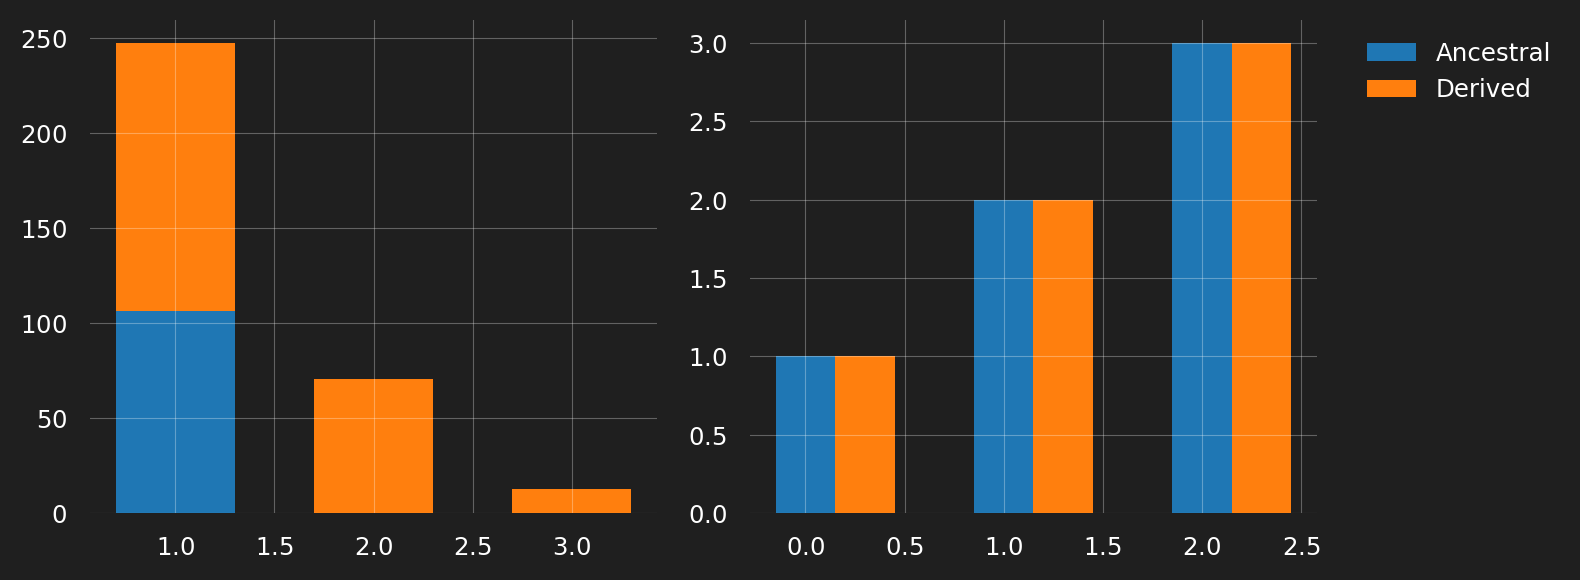

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def ton_plot(graph, indexer, sample_size):

    tons = range(1, sample_size)

    reward_matrix = graph.states().T
    tons = range(1, sample_size)
    rewards = [reward_matrix[indexer.lineage.p2i(n_descend=x, is_deriv=1)] for x in tons]
    der_tons_branch_len = [graph.expectation(r) for r in rewards]
    rewards = [reward_matrix[indexer.lineage.p2i(n_descend=x, is_deriv=0)] for x in tons]
    anc_tons_branch_len = [graph.expectation(r) for r in rewards]

    records = [(t, b, 1) for t, b in zip(tons, der_tons_branch_len)] + \
            [(t, b, 0) for t, b in zip(tons, anc_tons_branch_len)]

    plot_df = pd.DataFrame().from_records(
        records, columns=['n_descend', 'branch_length', 'is_deriv']
    )

    fig, axes = plt.subplots(1, 2, figsize=(8, 3))

    width = 0.6
    bottom = np.zeros(len(tons))
    x = list(map(str, tons))

    for id_derived, idx in plot_df.groupby('is_deriv').groups.items():
        label = 'Derived' if id_derived else 'Ancestral'
        df = plot_df.loc[idx]
        color=f'C{id_derived}'
        x, y = df.n_descend, df.branch_length
        p = axes[0].bar(x, y, width, label=label, bottom=bottom, color=color)
        bottom += y

    x = np.arange(sample_size-1)  # the label locations
    width = 0.3  # the width of the bars
    multiplier = 0

    for id_derived, idx in plot_df.groupby('is_deriv').groups.items():
        label = 'Derived' if id_derived else 'Ancestral'
        df = plot_df.loc[idx]
        color=f'C{id_derived}'
        offset = width * multiplier
        rects = axes[1].bar(x + offset, df.n_descend, width, label=label)
    #    ax.bar_label(rects, padding=3)
        multiplier += 1    

    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

ton_plot(graph, indexer, sample_size)

Extract rewards:

In [ ]:
rewards = np.zeros((sample_size-1, graph.vertices_length()))
for i in range(sample_size-1):
    rewards[i, :] = np.sum(graph.states().T[indexer.lineage.p2i(n_descend=i)], axis=0)

Sample 1'ton, 2'ton, and 3'ton branch lengths as first, second and third observation feature. Each observation only has a single non-nan feature since each lineage is defined by a single feature.

In [ ]:
nr_observations = 1000
n = nr_observations
observed_data = np.zeros((n * (rewards.shape[0]), rewards.shape[0]), dtype=float)
observed_data[:] = np.nan
for i in range(rewards.shape[0]):
    observed_data[(i*n):((i+1)*n), i] = graph.sample(n, rewards=rewards[i])
np.random.shuffle(observed_data)
observed_data[:nr_observations] # just the first nr_observations rows
#np.nansum(observed_data, axis=0)
observed_data

array([[         nan, 412.80729325,          nan],
       [         nan,  92.12607588,          nan],
       [         nan,          nan,  23.16798764],
       ...,
       [  0.        ,          nan,          nan],
       [         nan,          nan,  39.77983929],
       [         nan,          nan,  22.61591414]], shape=(3000, 3))

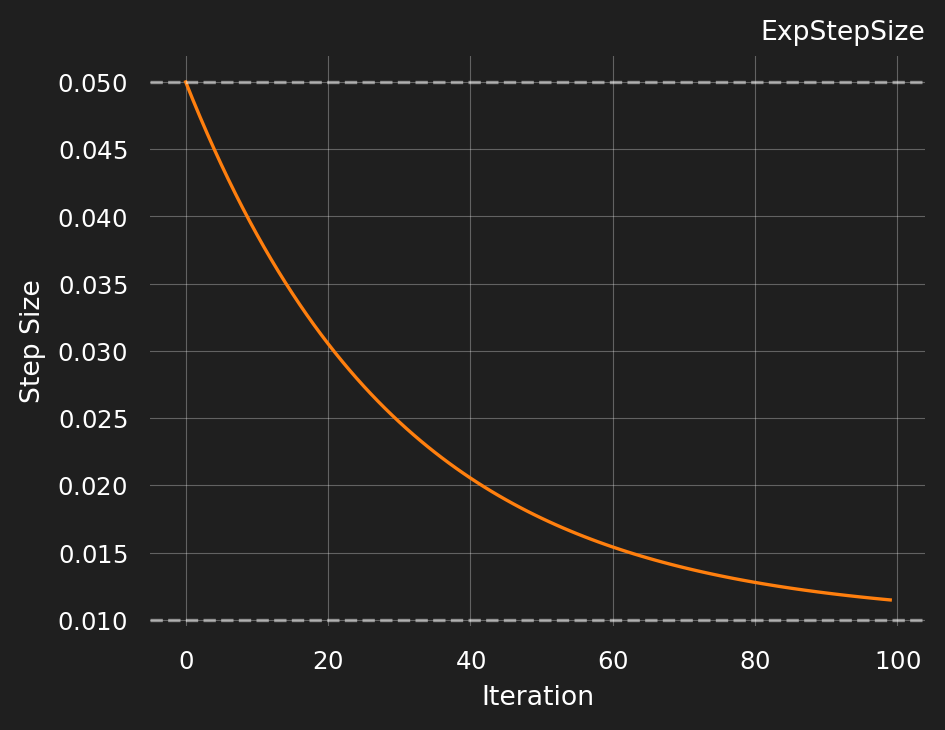

In [ ]:
from phasic import ExpStepSize, ExpRegularization, HalfCauchyPrior
step_schedule = ExpStepSize(first_step=0.05, last_step=0.01, tau=30.0)
step_schedule.plot(100);

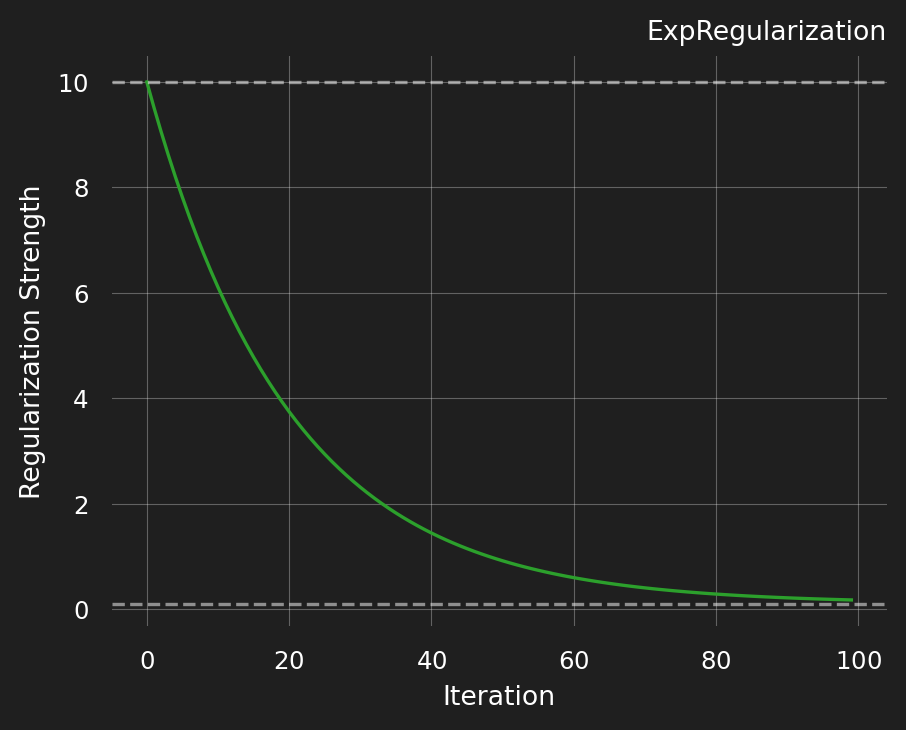

In [ ]:
reg_schedule = ExpRegularization(first_reg=10.0, last_reg=0.1, tau=20.0)
reg_schedule.plot(100) ;

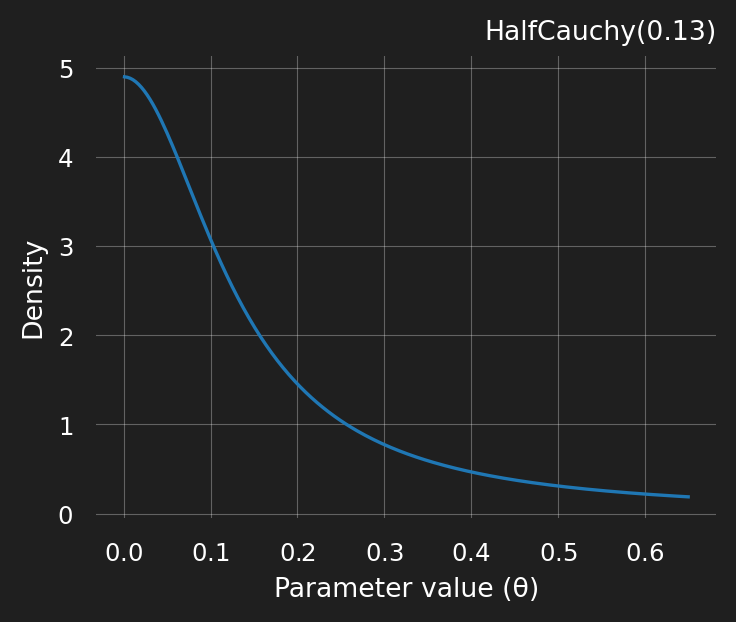

In [ ]:
prior = HalfCauchyPrior(ci=0.4, prob=0.8)
prior.plot();

In [ ]:
clear_model_cache()
clear_jax_cache()   

[DEBUG] phasic.graph_cache: GraphCache initialized: /Users/kmt/.phasic_cache/graphs
[INFO] phasic.graph_cache: Cleared 0 cached graphs


In [ ]:
from phasic import GaussPrior, ExpStepSize, Adam

#set_log_level('DEBUG')
svgd = graph.svgd(observed_data=observed_data, rewards=rewards, 
#                  prior=[GaussPrior(ci=[5, 15]), GaussPrior(ci=[0, 0.1])],
                 optimizer=Adam(0.25)
                  )
svgd.summary()
svgd.plot_convergence() ;

[DEBUG] phasic.c: Auto-selected granularity: 1024 (max_rate=512.00)
[ERROR] phasic.c: Computation produced NaN at vertex 1 (command 1: from=1 to=1 multiplier=nan result[to]=nan) - numerical catastrophe
ERROR:2026-01-17 23:33:50,200:jax._src.callback:94: jax.pure_callback failed
Traceback (most recent call last):
  File "/Users/kmt/phasic/.pixi/envs/default/lib/python3.11/site-packages/jax/_src/callback.py", line 92, in pure_callback_impl
    return tree_util.tree_map(np.asarray, callback(*args))
                                          ^^^^^^^^^^^^^^^
  File "/Users/kmt/phasic/.pixi/envs/default/lib/python3.11/site-packages/jax/_src/callback.py", line 70, in __call__
    return tree_util.tree_leaves(self.callback_func(*args, **kwargs))
                                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/kmt/phasic/.pixi/envs/default/lib/python3.11/site-packages/phasic/__init__.py", line 4497, in callback_fn
    return _compute_pmf_and_moments_cached(theta_np, times_np, 

ValueError: Model validation failed. Error: INTERNAL: CpuCallback error calling callback: Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/kmt/phasic/.pixi/envs/default/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
  File "/Users/kmt/phasic/.pixi/envs/default/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
  File "/Users/kmt/phasic/.pixi/envs/default/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 758, in start
  File "/Users/kmt/phasic/.pixi/envs/default/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start
  File "/Users/kmt/phasic/.pixi/envs/default/lib/python3.11/asyncio/base_events.py", line 608, in run_forever
  File "/Users/kmt/phasic/.pixi/envs/default/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once
  File "/Users/kmt/phasic/.pixi/envs/default/lib/pyth

In [ ]:
svgd.plot_trace()